In [ ]:
#Datacuratie

In [ ]:
#geurcategorisering
import re
import pandas as pd

# Pad naar je data
file_path = r"C:\Users\Nienke\Scriptie\odeuropa_samengevoegd.xlsx"
output_path = r"C:/Users/Nienke/Scriptie/Data/CategorieVolledig2.xlsx"


updated_categories = { 
    "BLOEMEN": [
        "roos","rozen","roozen","roosen","roosgeur",
        "lelie","lelien","viooltje","viooltjes","viool","violen",
        "narcis","tulp","bloem","bloemen","bloempjes","bloesem","bloesems",
        "hyacint","anjer","lavendel","blommen",
        "bloemkens","bloempken","roosenkrans","roosken","bloemgeur",
        "anjelier","lely"
    ],
    
    "PLANTEN": [
        "kruid","kruiden","kruyden","laurier","gras","blad","bladeren",
        "kruyd","thijm","rozemarijn","rosemarijn",
        "mos","heester","struyck","plant","plantkens","kruidnagel"
    ],
    
    "SPECERIJEN": [
        "saffraan","mirre","nardus","cassie","kaneel","caneel",
        "muskaat","nootmuskaat","gember","kardemom","kanneel",
        "kruidnagel","peper","foelie","koriander","anijs"
    ],
    
    "BOMEN_HOUT": [
        "oranjeboom","ceder","sandelhout","mirreboom","dennen",
        "eik","spar","bosch","hout","bos",
        "boom","houtgeur","houtachtigh","boomen","cipressen","laurier","palm"
    ],
    
    "WIERROOK_REUKWERK": [
        "wierook","reukwerk","geurwerk","reekwerk", "oly", "olie", "olien", "oliën", "olyen", "reuckwerk"
    ],
    
    "MUSKUS": [
        "muskus","muscus","moschus","muskusgeur","moscus"
    ],
    
    "BALSEM_RESINEN": [
        "balsem","amber","hars","gom","balssem",
        "mirre","galbanum","opobalsamum","terpentijn","storax"
    ],
    
    "ZWAVEL": [
        "zwavel","zwavellucht","zwavelreuk","zwavelstank",
        "zwavelagtig","zwavelachtige","swavel","zwaveldamp",
        "sulphur","swavelreuck","swavelgeur"
    ],
    
    "ROOK": [
        "rook","rooklucht","rookachtig","smook",
        "brand","brandlucht","verbrand","brandend",
        "rookken","branden","aenbrand","smeulend","smeulrook"
    ],
    
    "DAMP": [
        "damp","dampen","stikdamp","stiklucht","graften",
        "mistaen","nevel","walm","dampkens","rookdamp"
    ],
    
    "BEDERF": [
        "kadaver","bederf","bedorven","muf","muffig","goor","etter",
        "bloedlucht","rottend","rottende","rotte","rotting","graf",
        "verrotting","vergaan","ontbinding","lijfgeur", "dood", "doden", "sterven"
    ],

    "FRUIT": [
        "appel","appelen","peer","peren","druif","druiven",
        "aardbei","aardbeziën","meloen","meloenen","ananas",
        "vijg","vijgen","pruim","pruimen","kers","kersen","sinaasappel",
        "fruitgeur","fruyt","citroen","mandel","granateappel"
    ],
    
    "ETEN_DRINKEN": [
        "kaas","vlees","brood","wijn","bier","spijs","drank",
        "maaltijd","wijnen","spijse","eten","voedsel","kost","gerecht","brouwsels","gebraden"
    ],
    
    "STANK_ALGEMEEN": [
        "stank","stanck","stinck","stinckt","stinckende",
        "stinkend","stinkende","stink","stinken","stinkgeur","onrijn","vuylreuck"
    ],
    
    "POSITIEF_ALGEMEEN": [
        "geurig","geurige","geuriger","geurigste","geurigh",
        "hemelgeur","aromaticus","zoetgeur","edelgeur",
        "soeten","soet","zoet","zoeten",
        "parfumeerden","parfum","parfumen",
        "perfumeerden","perfumeren","parfumeren",
        "welriekend","aangenaamreuck","schoongeur","vriendelijckegeur",
        "welrieckende", "aangenaam", "aangename", "lekker", "fijn", "fris"
    ],
    
    "OVERIGEN_ONBEKEND": [
        "aluyn","kribbe","riedt","drincken","sondaer","menschen","tonge",
        "revieren","helschuym","zonden","zeyden","verdoemen","geesten",
        "schuym","zondenlucht", "reuck", "reuk", 'riek', 'reek'
    ],
    
    "WATER_VOCHT": [
        "water","wateren","waters","waeter", "vocht"
    ],

    "LUCHT": [
        "lucht", "locht"
    ]
}

category_sentiment = {
    "BLOEMEN": "POS",
    "PLANTEN": "POS",
    "SPECERIJEN": "POS",
    "BOMEN_HOUT": "POS",
    "WIERROOK_REUKWERK": "POS",
    "MUSKUS": "POS",
    "BALSEM_RESINEN": "POS",
    "ZWAVEL": "NEG",
    "ROOK": "NEG",
    "DAMP": "NEG",
    "BEDERF": "NEG",
    "FRUIT": "POS",
    "ETEN_DRINKEN": "POS",
    "STANK_ALGEMEEN": "NEG",
    "POSITIEF_ALGEMEEN": "POS",
    "OVERIGEN_ONBEKEND": "NEU",
    "OVERIG": "NEU",
    "WATER_VOCHT": "NEG",
    "LUCHT": "NEU}

# Categorieën opdelen in specifiek vs algemeen
general_categories = {"OVERIGEN_ONBEKEND", "STANK_ALGEMEEN", "POSITIEF_ALGEMEEN"}
specific_categories = [cat for cat in updated_categories.keys() if cat not in general_categories]

# -----------------------------------------------------------------
# Hulpfuncties
# -----------------------------------------------------------------
def is_empty(val):
    """Controleer of cel leeg of whitespace is."""
    return pd.isna(val) or (isinstance(val, str) and val.strip() == "")

def split_tokens(text):
    """Split een tekstcel in tokens op gebruikelijke scheidingstekens."""
    if pd.isna(text):
        return []
    parts = re.split(r"[|\-/,;]+", str(text))
    return [p.strip() for p in parts if p.strip()]

def match_token_to_category(token, allowed_cats=None):
    """
    Geef de eerste matchende categorie voor een token.
    allowed_cats: optionele subset van categorieën om in te zoeken.
    """
    t_low = token.lower()
    if t_low in ("lijk", "lijken"):
        return None, None
    search_space = updated_categories if allowed_cats is None else {k: updated_categories[k] for k in allowed_cats}
    for cat, wordlist in search_space.items():
        for pat in wordlist:
            if re.search(rf"\b{re.escape(pat.lower())}\b", t_low) or pat.lower() in t_low:
                return cat, pat
    return None, None

def find_first_match(row, columns, allowed_cats):
    """Doorzoek gegeven kolommen in volgorde; retourneer eerste match (cat, pat, kolom)."""
    for col in columns:
        text = row.get(col)
        for tok in split_tokens(text):
            cat, pat = match_token_to_category(tok, allowed_cats)
            if cat is not None:
                return cat, pat, col
    return None, None, None

# -----------------------------------------------------------------
# Hoofdclassificatie
# -----------------------------------------------------------------
def classify_row(row):
    # 1. Houd bestaande classificatie ongemoeid
    if not is_empty(row.get("Smell_Category", None)):
        return pd.Series([None, row["Smell_Category"], None, "Bestaand"])

    # 2. Eerst: specifieke categorieën in hoofdvelden
    main_cols = ["Smell_Word", "Smell_Source", "Odour_Carrier", "Evoked_Odorant"]
    cat, pat, col = find_first_match(row, main_cols, specific_categories)
    if cat:
        return pd.Series([pat, cat, category_sentiment.get(cat, "NEU"), col])

    # 3. Dan: specifieke categorieën in Sentence
    cat, pat, col = find_first_match(row, ["Sentence"], specific_categories)
    if cat:
        return pd.Series([pat, cat, category_sentiment.get(cat, "NEU"), "Sentence"])

    # 4. Dan: specifieke categorieën in SentenceBefore / SentenceAfter
    cat, pat, col = find_first_match(row, ["SentenceBefore", "SentenceAfter"], specific_categories)
    if cat:
        return pd.Series([pat, cat, category_sentiment.get(cat, "NEU"), col])

    # 5. Nog niets gevonden → zoek nu algemene categorieën
    cat, pat, col = find_first_match(row, main_cols + ["Sentence", "SentenceBefore", "SentenceAfter"], general_categories)
    if cat:
        return pd.Series([pat, cat, category_sentiment.get(cat, "NEU"), col])

    # 6. Geen enkele match → "OVERIGEN_ONBEKEND"
    return pd.Series([None, "OVERIGEN_ONBEKEND", "NEU", None])

# -----------------------------------------------------------------
# Uitvoeren
# -----------------------------------------------------------------
df = pd.read_excel(file_path, dtype=str)
df[["MatchedWord", "Smell_Category_New", "Sentiment", "MatchedColumn"]] = df.apply(classify_row, axis=1)

# Vul alleen lege Smell_Category aan
mask = df["Smell_Category"].apply(is_empty)
df.loc[mask, "Smell_Category"] = df.loc[mask, "Smell_Category_New"]

# Opslaan met nieuwe kolommen voor controle
df.to_excel(output_path, index=False)
print(f"Nieuwe categorieën toegevoegd aan lege rijen. Bestand opgeslagen als:\n{output_path}")

# Controlevoorbeeld
print(df.loc[mask, ["Smell_Word","Smell_Source","MatchedWord","Smell_Category","MatchedColumn"]].head(15))

In [ ]:
#Hoofdstuk 1

In [4]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

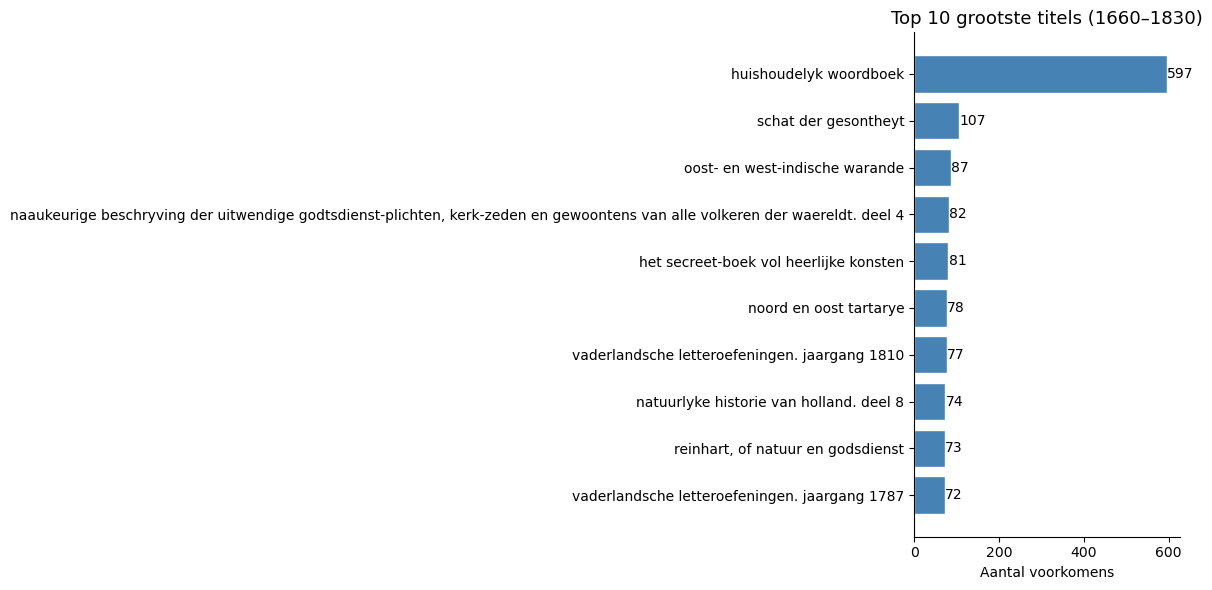

In [5]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# 1. Lees het Excel-bestand in
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

# 2. Filter op jaren 1660–1830
df_filtered = df[(df['year'] >= 1660) & (df['year'] <= 1830)]

# 3. Tel hoe vaak elke titel voorkomt en pak top 10
title_counts = Counter(df_filtered['title'].dropna().astype(str))
top10 = title_counts.most_common(10)
labels = [titel for titel, count in top10]
values = [count for titel, count in top10]

# 4. Maak de bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels[::-1], values[::-1], color="steelblue", edgecolor="white")

# 5. Voeg aantallen toe aan het einde van elke balk
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)

ax.set_xlabel("Aantal voorkomens")
ax.set_title("Top 10 grootste titels (1660–1830)", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("barchart_top10.png", dpi=150)
plt.show()

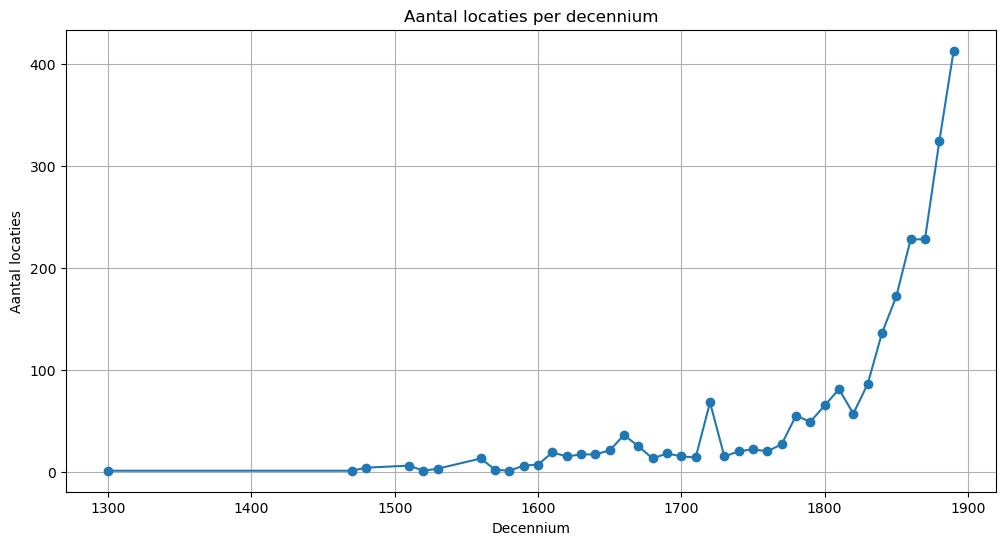

In [6]:

df['decade'] = (df['year'] // 10) * 10
locations = df.dropna(subset=['Location'])
locations_per_decade = locations.groupby('decade').size()

plt.figure(figsize=(12,6))
plt.plot(locations_per_decade.index, locations_per_decade.values, marker='o')

plt.xlabel("Decennium")
plt.ylabel("Aantal locaties")
plt.title("Aantal locaties per decennium")
plt.grid(True)

plt.show()

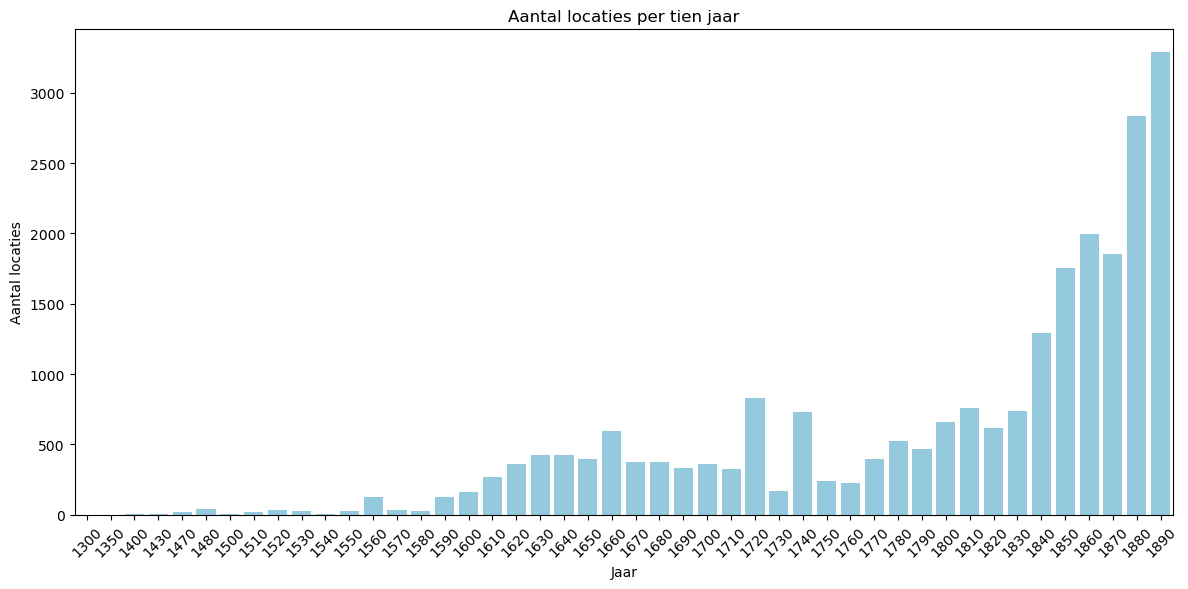

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['year'] = pd.to_numeric(df['year'], errors='coerce')

df['decade'] = (df['year'] // 10) * 10


tellingen = df.groupby('decade').size().reset_index(name='aantal')

plt.figure(figsize=(12, 6))
sns.barplot(data=tellingen, x='decade', y='aantal', color="skyblue")

plt.title('Aantal locaties per tien jaar')
plt.xlabel('Jaar')
plt.ylabel('Aantal locaties')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



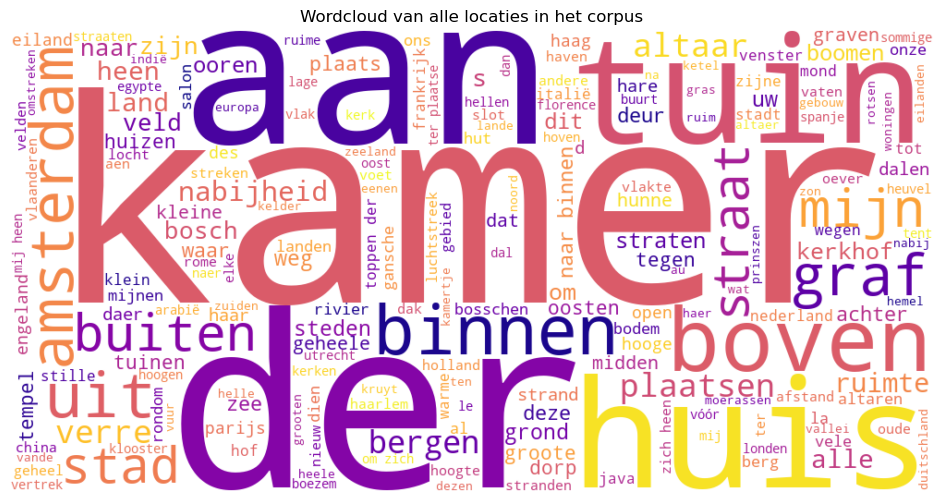

In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# stopwoorden
custom_stopwords = {"een", "den", "de", "het", "op", "van", "hier", "daar", "t", "door", "bij", "te", "en", "voor", "rond", "langs", "die", "deeze", "eene", "onder"}  
stopwords = STOPWORDS.union(custom_stopwords)

# Alle locaties combineren in één tekststring
text = " ".join(df['Location'].dropna().astype(str).str.lower())

# Maak wordcloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stopwords,
    colormap="plasma"  # je kan ook "viridis", "Reds", "Greens", etc. kiezen
).generate(text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud van alle locaties in het corpus")
plt.show()


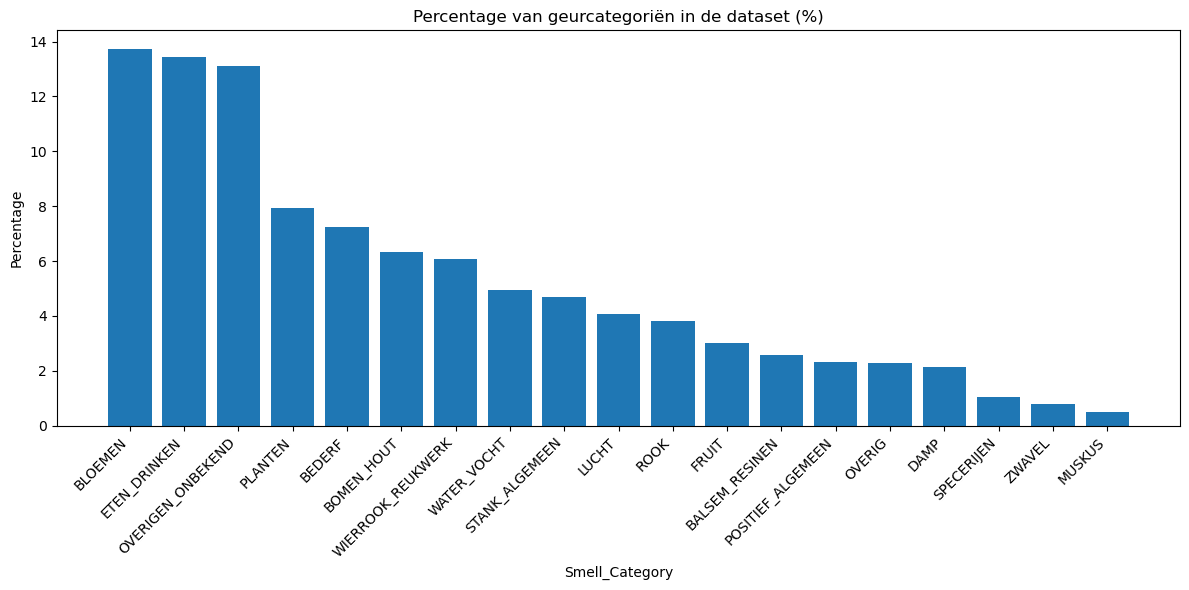

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

# Verwerk je data
df = df[(df["year"] >= 1660) & (df["year"] <= 1830)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()
# Tellen van de Smell_Categories
counts = df["Smell_Category"].value_counts(dropna=False)

# Percentages berekenen
percentages = counts / counts.sum() * 100

# Data samenvoegen
result = pd.DataFrame({
    "Aantal": counts,
    "Percentage": percentages
}).reset_index().rename(columns={"index": "Smell_Category"})

# Sorteren op percentage
result = result.sort_values(by="Percentage", ascending=False)

# Plotten
plt.figure(figsize=(12,6))
plt.bar(result["Smell_Category"], result["Percentage"])
plt.title("Percentage van geurcategoriën in de dataset (%)")
plt.xlabel("Smell_Category")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


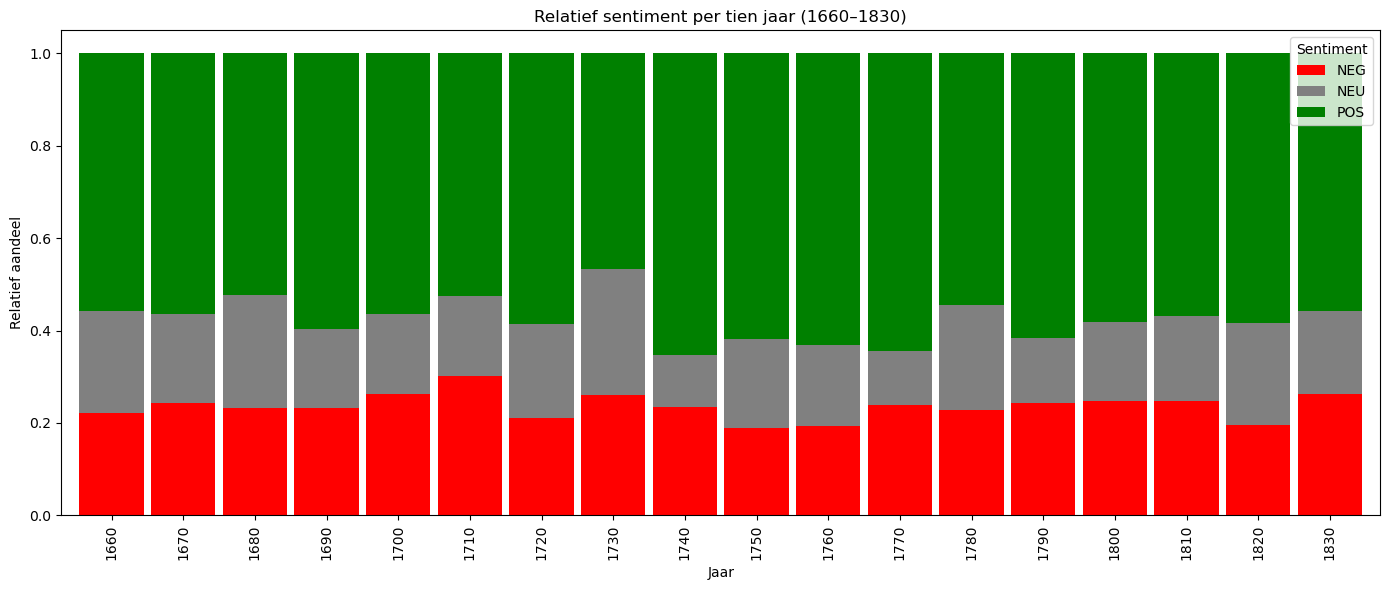

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\loc3_sentiment_categorie2.xlsx")

# Zorg dat de jaartal-kolom numeriek is
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Filter de periode 1660–1830
df = df[(df["year"] >= 1660) & (df["year"] <= 1830)]

# Decennium toevoegen
df["Decade"] = (df["year"] // 10) * 10

# Tellen per jaar en sentiment
counts = df.groupby(["Decade", "Sentiment"]).size().unstack(fill_value=0)

# Relatief aandeel per jaar
relative = counts.div(counts.sum(axis=1), axis=0)

colors = {
    "POS": "green",
    "NEG": "red",
    "NEU": "gray"
}

relative.plot(
    kind="bar",
    stacked=True,
    color=[colors[col] for col in relative.columns],
    figsize=(14,6),
    width=0.9

plt.title("Relatief sentiment per tien jaar (1660–1830)")
plt.xlabel("Jaar")
plt.ylabel("Relatief aandeel")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

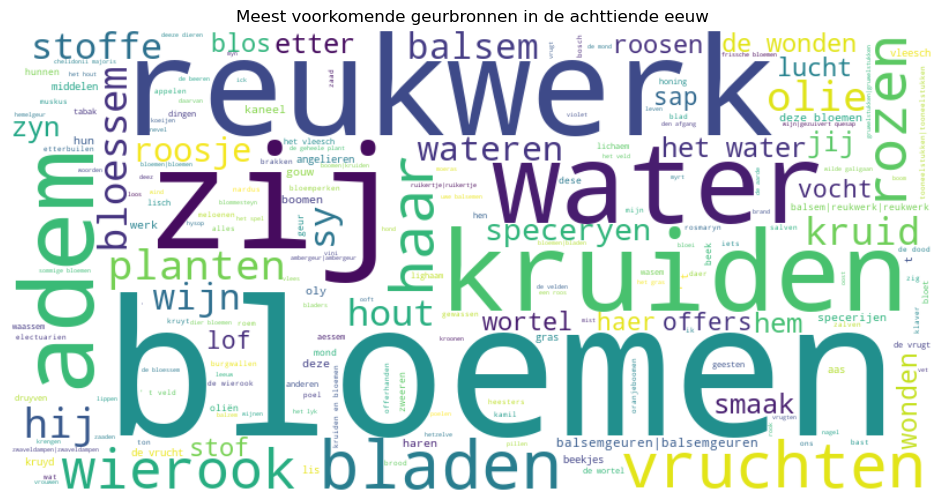

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from collections import defaultdict


# Termen die je niet in de wordcloud wilt
terms_to_exclude = {"het", "die", "dat", "mij", "my", "dit"}

# Verwerk je data
df = df[(df["year"] >= 1660) & (df["year"] <= 1830)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()

# Pas de mapping toe, met fallback naar originele term als die niet in de mapping zit
sources = sources[~sources.isin(terms_to_exclude)]
value_counts = sources.value_counts()
sources = sources.apply(lambda x: custom_mapping.get(x, x))
filtered_counts = {term: count for term, count in value_counts.items() if term not in terms_to_exclude}
value_counts = sources.value_counts()


clusters = defaultdict(int)
used = set()
threshold = 85

for term in value_counts.index:
    if term in used:
        continue
    total_count = value_counts[term]
    used.add(term)
    for other_term in value_counts.index:
        if other_term in used:
            continue
        similarity = fuzz.token_sort_ratio(term, other_term)
        if similarity >= threshold:
            total_count += value_counts[other_term]
            used.add(other_term)
    clusters[term] = total_count

# Maak de wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(clusters)

# Plotten
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Meest voorkomende geurbronnen in de achttiende eeuw")
plt.show()

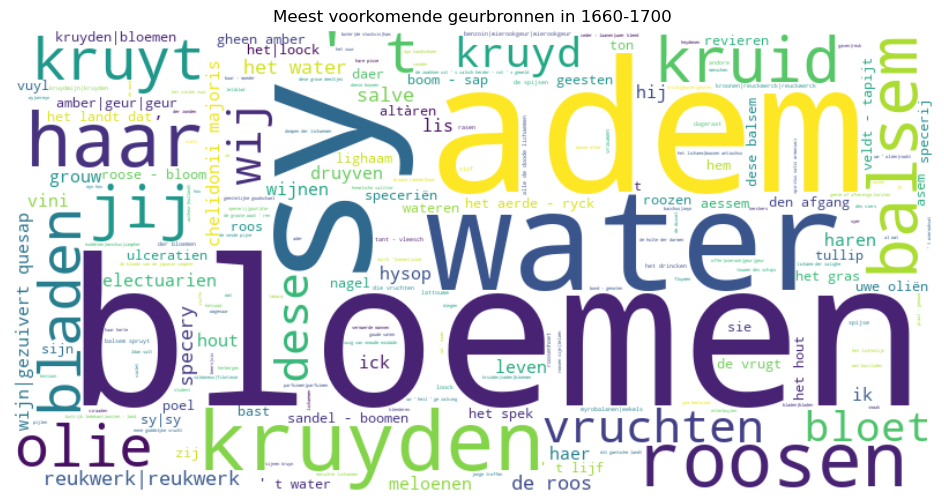

In [61]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from collections import defaultdict


# Termen die je niet in de wordcloud wilt
terms_to_exclude = {"het", "die", "dat", "mij", "my", "dit"}
import pandas as pd

# Verwerk je data
df = df[(df["year"] >= 1660) & (df["year"] <= 1700)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()

# Pas de mapping toe, met fallback naar originele term als die niet in de mapping zit
sources = sources[~sources.isin(terms_to_exclude)]
value_counts = sources.value_counts()
sources = sources.apply(lambda x: custom_mapping.get(x, x))
filtered_counts = {term: count for term, count in value_counts.items() if term not in terms_to_exclude}
value_counts = sources.value_counts()


clusters = defaultdict(int)
used = set()
threshold = 85

for term in value_counts.index:
    if term in used:
        continue
    total_count = value_counts[term]
    used.add(term)
    for other_term in value_counts.index:
        if other_term in used:
            continue
        similarity = fuzz.token_sort_ratio(term, other_term)
        if similarity >= threshold:
            total_count += value_counts[other_term]
            used.add(other_term)
    clusters[term] = total_count

# Maak de wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(clusters)

# Plotten
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Meest voorkomende geurbronnen in 1660-1700")
plt.show()

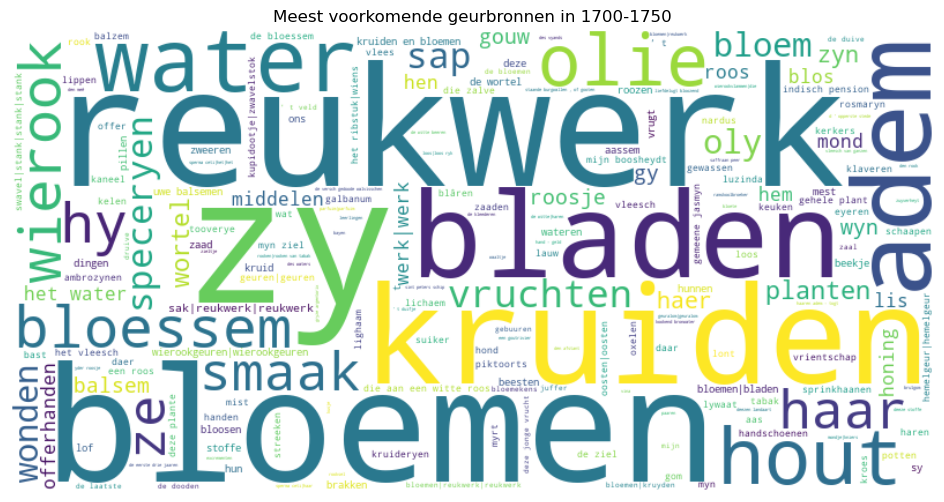

In [74]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from collections import defaultdict


# Termen die je niet in de wordcloud wilt
terms_to_exclude = {"het", "die", "dat", "mij", "my", "dit"}

custom_mapping = {
    "reukwerk|reukwerk" : "reukwerk",
    "reukwerken|reukwerken" : "reukwerk",
    "balsemgeuren|balsemgeuren" : "balsem",
    "wierookgeur|wierookgeur" : "wierook"
}

# Verwerk je data
df = df[(df["year"] >= 1700) & (df["year"] <= 1750)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()

# Pas de mapping toe, met fallback naar originele term als die niet in de mapping zit
sources = sources[~sources.isin(terms_to_exclude)]
value_counts = sources.value_counts()
sources = sources.apply(lambda x: custom_mapping.get(x, x))
filtered_counts = {term: count for term, count in value_counts.items() if term not in terms_to_exclude}
value_counts = sources.value_counts()


clusters = defaultdict(int)
used = set()
threshold = 85

for term in value_counts.index:
    if term in used:
        continue
    total_count = value_counts[term]
    used.add(term)
    for other_term in value_counts.index:
        if other_term in used:
            continue
        similarity = fuzz.token_sort_ratio(term, other_term)
        if similarity >= threshold:
            total_count += value_counts[other_term]
            used.add(other_term)
    clusters[term] = total_count

# Maak de wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(clusters)

# Plotten
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Meest voorkomende geurbronnen in 1700-1750")
plt.show()

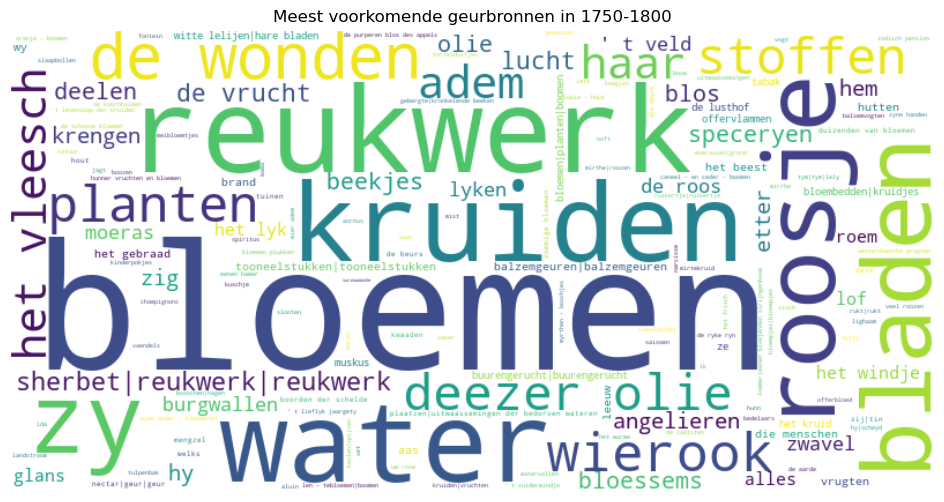

In [101]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from collections import defaultdict


# Termen die je niet in de wordcloud wilt
terms_to_exclude = {"het", "die", "dat", "mij", "my", "dit"}
custom_mapping = {
    "reukwerk|reukwerk" : "reukwerk",
    "reukwerken|reukwerken" : "reukwerk",
    "balsemgeuren|balsemgeuren" : "balsem",
    "wierookgeur|wierookgeur" : "wierook"
}


# Verwerk je data
df = df[(df["year"] >= 1750) & (df["year"] <= 1800)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()

# Pas de mapping toe, met fallback naar originele term als die niet in de mapping zit
sources = sources[~sources.isin(terms_to_exclude)]
value_counts = sources.value_counts()
sources = sources.apply(lambda x: custom_mapping.get(x, x))
filtered_counts = {term: count for term, count in value_counts.items() if term not in terms_to_exclude}
value_counts = sources.value_counts()


clusters = defaultdict(int)
used = set()
threshold = 65

for term in value_counts.index:
    if term in used:
        continue
    total_count = value_counts[term]
    used.add(term)
    for other_term in value_counts.index:
        if other_term in used:
            continue
        similarity = fuzz.token_sort_ratio(term, other_term)
        if similarity >= threshold:
            total_count += value_counts[other_term]
            used.add(other_term)
    clusters[term] = total_count

# Maak de wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(clusters)

# Plotten
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Meest voorkomende geurbronnen in 1750-1800")
plt.show()

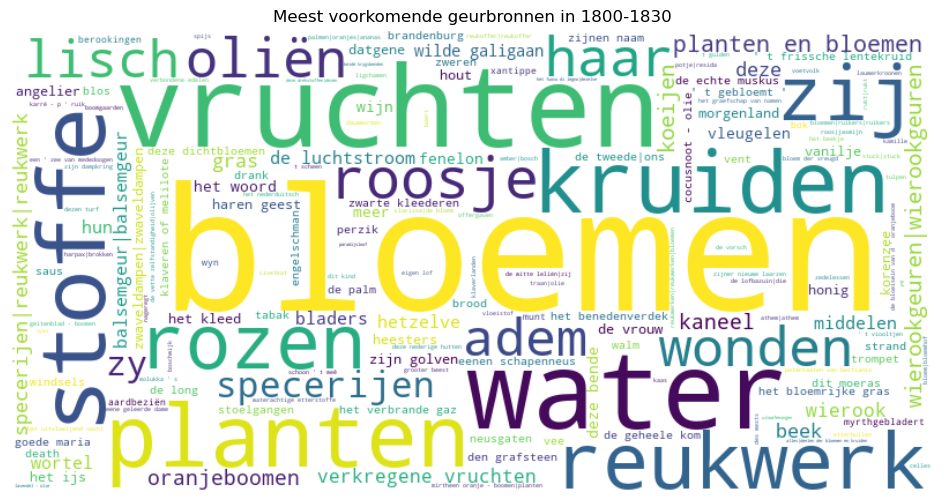

In [100]:
import pandas as pd
df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from collections import defaultdict


# Termen die je niet in de wordcloud wilt
terms_to_exclude = {"het", "die", "dat", "mij", "my", "dit"}
custom_mapping = {
    "reukwerk|reukwerk" : "reukwerk",
    "reukwerken|reukwerken" : "reukwerk",
    "balsemgeuren|balsemgeuren" : "balsem",
    "wierookgeur|wierookgeur" : "wierook"
}


# Verwerk je data
df = df[(df["year"] >= 1800) & (df["year"] <= 1830)]
sources = df['Smell_Source'].dropna().str.lower().str.strip()

# Pas de mapping toe, met fallback naar originele term als die niet in de mapping zit
sources = sources[~sources.isin(terms_to_exclude)]
value_counts = sources.value_counts()
sources = sources.apply(lambda x: custom_mapping.get(x, x))
filtered_counts = {term: count for term, count in value_counts.items() if term not in terms_to_exclude}
value_counts = sources.value_counts()


clusters = defaultdict(int)
used = set()
threshold = 60

for term in value_counts.index:
    if term in used:
        continue
    total_count = value_counts[term]
    used.add(term)
    for other_term in value_counts.index:
        if other_term in used:
            continue
        similarity = fuzz.token_sort_ratio(term, other_term)
        if similarity >= threshold:
            total_count += value_counts[other_term]
            used.add(other_term)
    clusters[term] = total_count

# Maak de wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(clusters)

# Plotten
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Meest voorkomende geurbronnen in 1800-1830")
plt.show()

In [ ]:
#Hoofdstuk 2

C:\Users\Nienke\AppData\Local\Temp\ipykernel_14460\62889832.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tellingen = df_filtered.groupby(['periode', 'Categorie']).size().reset_index(name='aantal')


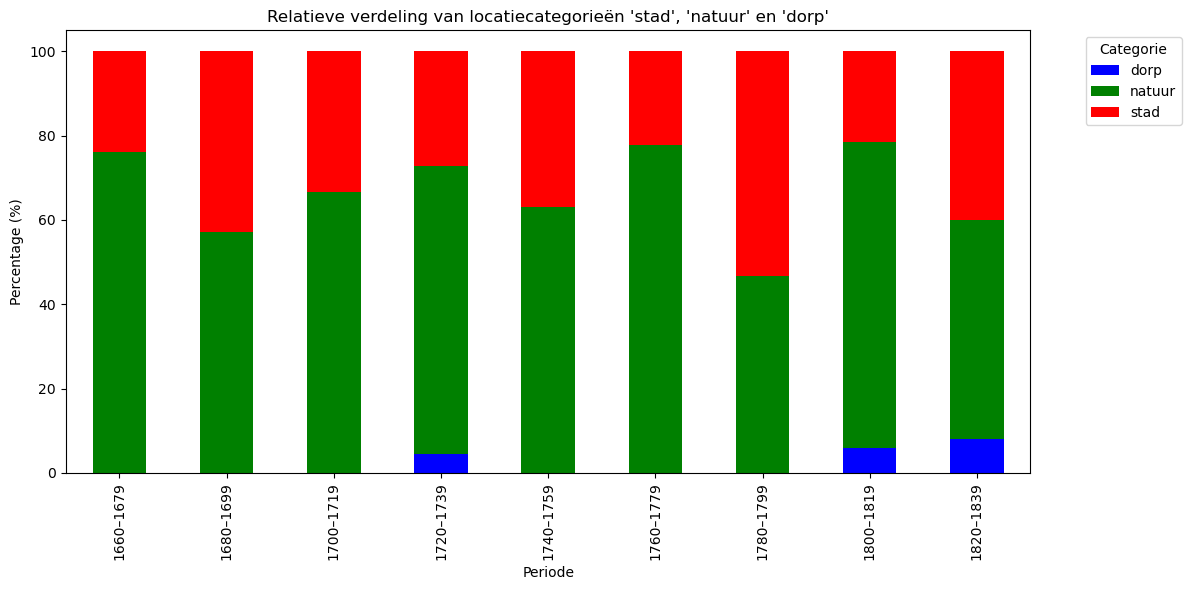

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\CategorieVolledig2.xlsx") 
df_filtered = df[df['Categorie'].isin(['stad', 'natuur', 'dorp'])].copy()

# Maak periodes van 20 jaar
bins = range(df_filtered['year'].min(), df_filtered['year'].max() + 20, 20)
labels = [f"{start}–{end-1}" for start, end in zip(bins[:-1], bins[1:])]

df_filtered['periode'] = pd.cut(
    df_filtered['year'],
    bins=bins,
    labels=labels,
    right=False
)

# Aantallen per periode per categorie
tellingen = df_filtered.groupby(['periode', 'Categorie']).size().reset_index(name='aantal')

# Pivot zodat categorieën kolommen worden
pivot_df = tellingen.pivot(index='periode', columns='Categorie', values='aantal').fillna(0)

# Zet om naar percentages binnen elke periode
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Kleuren per categorie
kleuren = {
    'dorp': 'blue',
    'stad': 'red',
    'natuur': 'green'
}

# Stacked bar chart
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[kleuren.get(col, 'gray') for col in pivot_df.columns]
)

plt.title("Relatieve verdeling van locatiecategorieën 'stad', 'natuur' en 'dorp'")
plt.xlabel("Periode")
plt.ylabel("Percentage (%)")
plt.legend(title="Categorie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

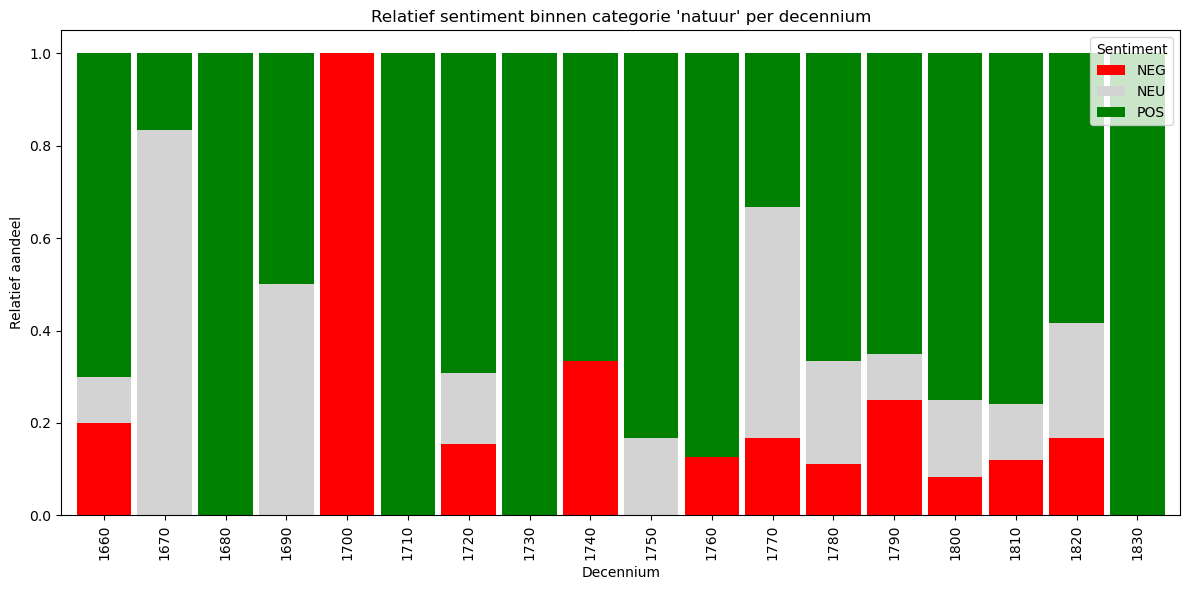

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\Definitief.xlsx") 

# Filter alleen categorie
stad_df = df[df["Categorie"] == "natuur"].copy()

# Decennium toevoegen
stad_df["Decennium"] = (stad_df["year"] // 10) * 10

# Groeperen per decennium en sentiment
sentiment_counts = stad_df.groupby(["Decennium", "Sentiment"]).size().unstack(fill_value=0)

# Relatief maken (percentage per decennium)
sentiment_rel = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0)

# Plot als bar chart
sentiment_rel.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.9,  # jouw verzoek voor bredere bars
    color={"POS": "green", "NEG": "red", "NEU": "lightgrey"}
)

plt.title("Relatief sentiment binnen categorie 'natuur' per decennium")
plt.xlabel("Decennium")
plt.ylabel("Relatief aandeel")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


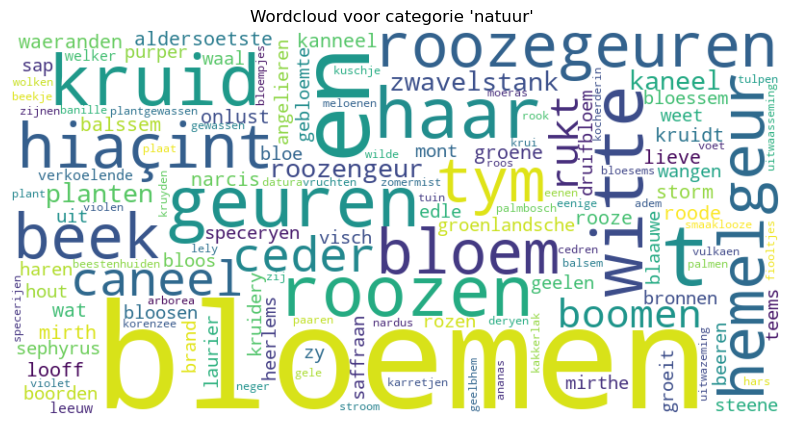

In [88]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\Definitief.xlsx") 

# Extra woorden die je wilt verwijderen uit de wordcloud
custom_stopwords = {"de", "het", "een", "die", "dit", "deze", "daar", 'eene', 'der', 'des', 'den', 'deeze', 'van', 'veele'}  # <-- voeg hier je lijst aan toe

# Combineer met de standaard stopwords van WordCloud
stopwords = STOPWORDS.union(custom_stopwords)

# Filter alleen de drie hoofd-categorieën
df_filtered = df[df['Categorie'].isin(['natuur'])].copy()

for categorie in df_filtered['Categorie'].unique():
    subset = df_filtered[df_filtered['Categorie'] == categorie]
    text = " ".join(subset['Smell_Source'].dropna().astype(str).str.lower())
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        colormap="viridis"
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor categorie '{categorie}' ")
    
    # Bewaar elke figuur apart
    plt.savefig(f"wordcloud_{categorie}.png", dpi=300, bbox_inches="tight")
    plt.show()


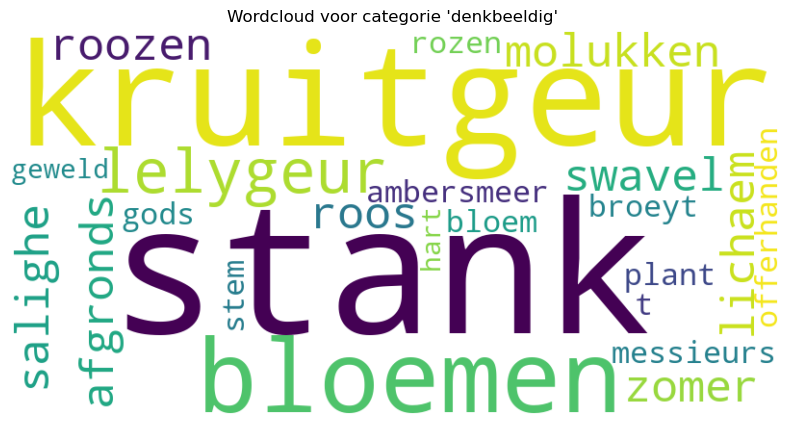

In [89]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\Definitief.xlsx") 

# Extra woorden die je wilt verwijderen uit de wordcloud
custom_stopwords = {"de", "het", "een", "die", "dit", "deze", "daar", 'eene', 'der', 'des', 'den', 'deeze', 'van', 'veele'}  # <-- voeg hier je lijst aan toe

# Combineer met de standaard stopwords van WordCloud
stopwords = STOPWORDS.union(custom_stopwords)

# Filter alleen de drie hoofd-categorieën
df_filtered = df[df['Categorie'].isin(['denkbeeldig'])].copy()

for categorie in df_filtered['Categorie'].unique():
    subset = df_filtered[df_filtered['Categorie'] == categorie]
    text = " ".join(subset['Smell_Source'].dropna().astype(str).str.lower())
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        colormap="viridis"
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor categorie '{categorie}' ")
    
    # Bewaar elke figuur apart
    plt.savefig(f"wordcloud_{categorie}.png", dpi=300, bbox_inches="tight")
    plt.show()


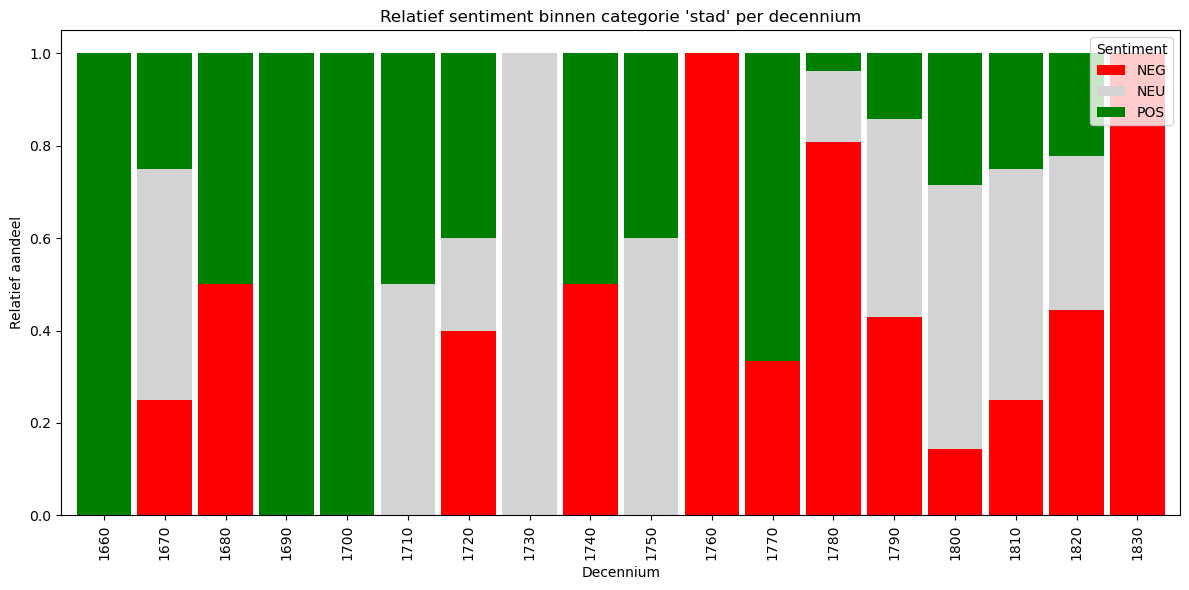

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\Definitief.xlsx") 

# Filter alleen categorie
stad_df = df[df["Categorie"] == "stad"].copy()

# Decennium toevoegen
stad_df["Decennium"] = (stad_df["year"] // 10) * 10

# Groeperen per decennium en sentiment
sentiment_counts = stad_df.groupby(["Decennium", "Sentiment"]).size().unstack(fill_value=0)

# Relatief maken (percentage per decennium)
sentiment_rel = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0)

# Plot als bar chart
sentiment_rel.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.9,  # jouw verzoek voor bredere bars
    color={"POS": "green", "NEG": "red", "NEU": "lightgrey"}
)

plt.title("Relatief sentiment binnen categorie 'stad' per decennium")
plt.xlabel("Decennium")
plt.ylabel("Relatief aandeel")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


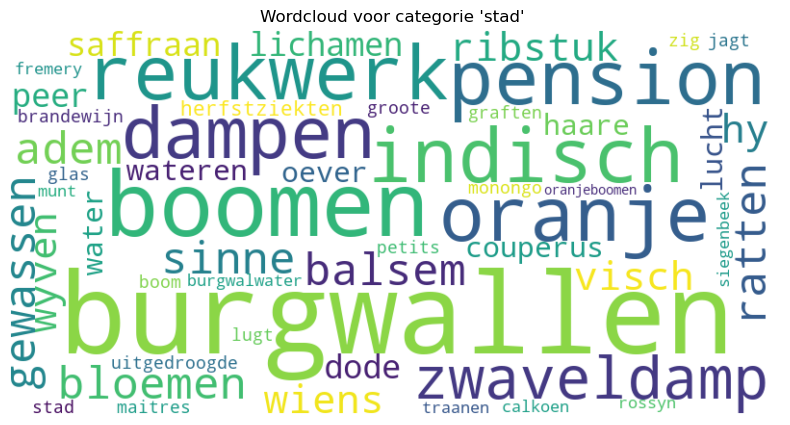

In [91]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r"C:\Users\Nienke\Scriptie\Data\Definitief.xlsx") 

# Extra woorden die je wilt verwijderen uit de wordcloud
custom_stopwords = {"de", "het", "een", "die", "dit", "deze", "daar", 'eene', 'der', 'des', 'den', 'deeze', 'van', 'veele'}  # <-- voeg hier je lijst aan toe

# Combineer met de standaard stopwords van WordCloud
stopwords = STOPWORDS.union(custom_stopwords)

# Filter alleen de drie hoofd-categorieën
df_filtered = df[df['Categorie'].isin(['stad'])].copy()

for categorie in df_filtered['Categorie'].unique():
    subset = df_filtered[df_filtered['Categorie'] == categorie]
    text = " ".join(subset['Smell_Source'].dropna().astype(str).str.lower())
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        colormap="viridis"
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor categorie '{categorie}' ")
    
    # Bewaar elke figuur apart
    plt.savefig(f"wordcloud_{categorie}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
#Hoofdstuk 3

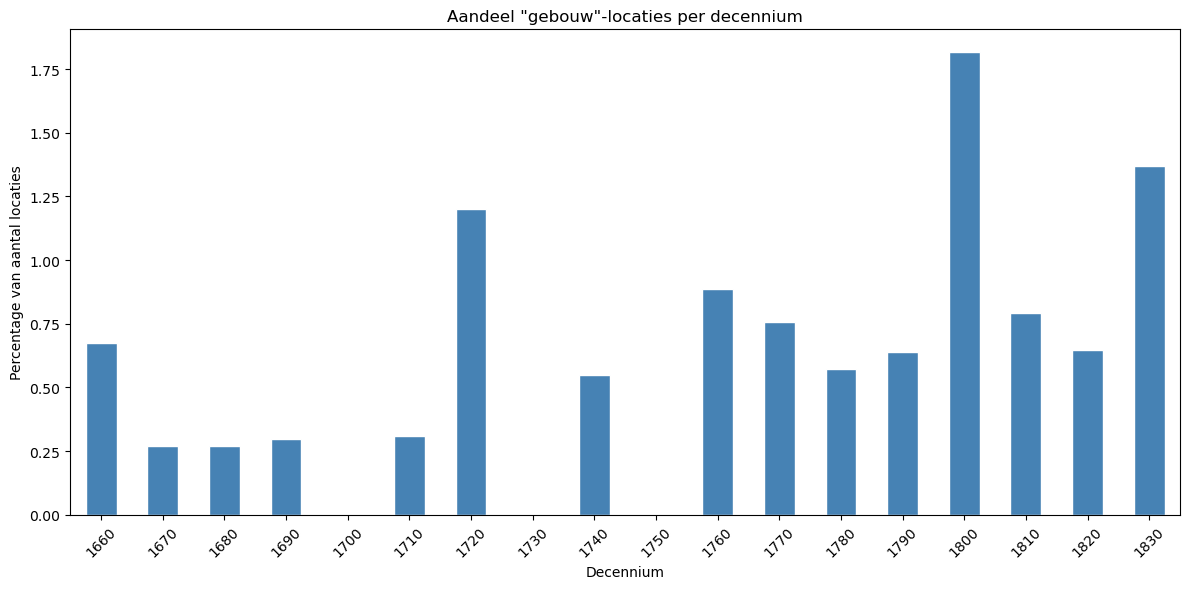

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Laad bestand 
file_path = r"C:/Users/Nienke/Scriptie/Data/CategorieVolledig2.xlsx"
df = pd.read_excel(file_path)
df = df[(df['year'] >= 1660) & (df['year'] <= 1830)]

# Maak een decenniumkolom
df['decennium'] = (df['year'] // 10) * 10

# Tel gebouw-locaties en totaal per decennium
gebouw = df[df['Categorie'] == 'gebouw'].groupby('decennium').size()
totaal = df.groupby('decennium').size()

# Bereken relatief aandeel
relatief = (gebouw / totaal * 100).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
relatief.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_xlabel('Decennium')
ax.set_ylabel('Percentage van aantal locaties')
ax.set_title('Aandeel "gebouw"-locaties per decennium')
ax.set_xticklabels([f'{int(d)}' for d in relatief.index], rotation=45)

plt.tight_layout()
plt.savefig('gebouw_per_decennium.png', dpi=150)
plt.show()

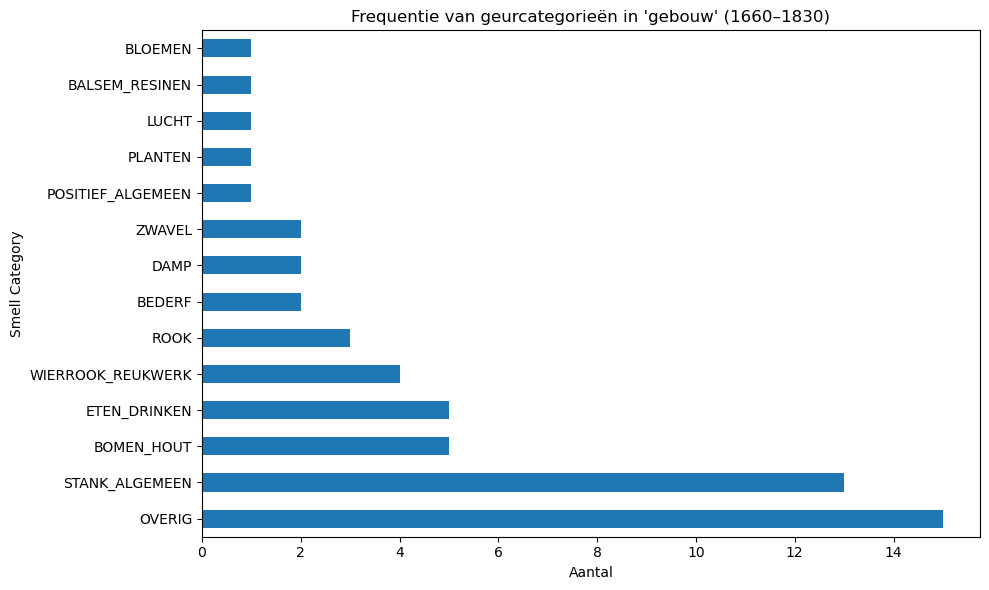

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:/Users/Nienke/Scriptie/Data/CategorieVolledig2.xlsx"
df = pd.read_excel(file_path)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

filtered = df[
    (df["Categorie"] == "gebouw") &
    (df["year"] >= 1660) &
    (df["year"] <= 1830)
]

smell_freq = filtered["Smell_Category"].value_counts()

plt.figure(figsize=(10,6))
smell_freq.plot(kind="barh")

plt.title("Frequentie van geurcategorieën in 'gebouw' (1660–1830)")
plt.xlabel("Aantal")
plt.ylabel("Smell Category")

plt.tight_layout()
plt.show()

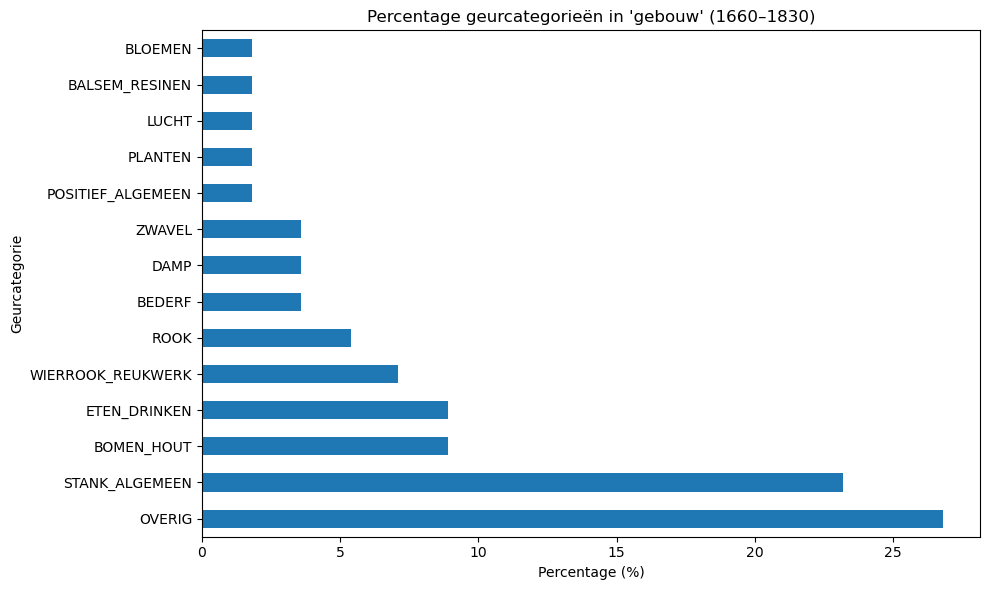

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:/Users/Nienke/Scriptie/Data/CategorieVolledig2.xlsx"
df = pd.read_excel(file_path)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

filtered = df[
    (df["Categorie"] == "gebouw") &
    (df["year"] >= 1660) &
    (df["year"] <= 1830)
]

smell_pct = (
    filtered["Smell_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

ax = smell_pct.plot(kind="barh", figsize=(10,6))


plt.title("Percentage geurcategorieën in 'gebouw' (1660–1830)")
plt.xlabel("Percentage (%)")
plt.ylabel("Geurcategorie")

plt.tight_layout()
plt.show()

C:\Users\Nienke\AppData\Local\Temp\ipykernel_14460\3096059937.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["decade"] = (filtered["year"] // 10) * 10


<Figure size 1400x700 with 0 Axes>

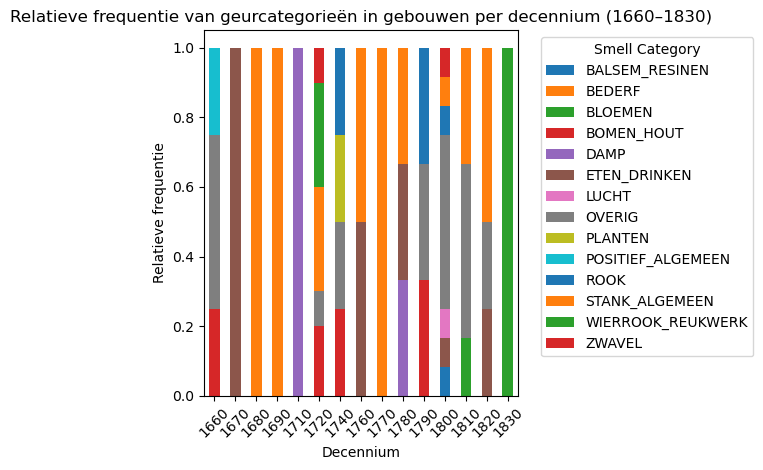

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:/Users/Nienke/Scriptie/Data/CategorieVolledig2.xlsx"
df = pd.read_excel(file_path)

# Zorg dat year numeriek is
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Filter op gebouwen en tijdsperiode
filtered = df[
    (df["Categorie"] == "gebouw") &
    (df["year"] >= 1660) &
    (df["year"] <= 1830)
]

# Decennium maken
filtered["decade"] = (filtered["year"] // 10) * 10

# Frequentietabel
freq_table = pd.crosstab(filtered["decade"], filtered["Smell_Category"])

# Relatieve frequenties berekenen
rel_freq = freq_table.div(freq_table.sum(axis=1), axis=0)

# Plotten
plt.figure(figsize=(14,7))
rel_freq.plot(kind="bar", stacked=True)

plt.title("Relatieve frequentie van geurcategorieën in gebouwen per decennium (1660–1830)")
plt.xlabel("Decennium")
plt.ylabel("Relatieve frequentie")

plt.xticks(rotation=45)
plt.legend(title="Smell Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()